# Step 1: I Loaded the train data set

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

In [2]:
Train_data = pd.read_excel(r"C:\Users\Anthony Bannerman\Documents\heart disease analysis\train.xlsx")

In [3]:
Train_data.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
Train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [5]:
Train_data.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


# Convert categorical column target variable to numeric using the map function

In [6]:
df = Train_data.copy()

In [7]:
#convert target to 0/1
df['Heart Disease'] = df['Heart Disease'].map({'Presence':1, 'Absence':0})

In [8]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


In [9]:
# Check unique values in target
print(df['Heart Disease'].value_counts())

Heart Disease
0    347546
1    282454
Name: count, dtype: int64


# Identify categorical and numeric features

In [10]:
categorical_cols = ['Sex', 'Chest pain type', 'EKG results', 'Exercise angina', 'Slope of ST', 'Thallium']
numeric_cols = [col for col in df.columns if col not in categorical_cols + ['Age', 'id', 'Heart Disease']]

# One-hot encode categorical variables

In [11]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Correlation Analysis

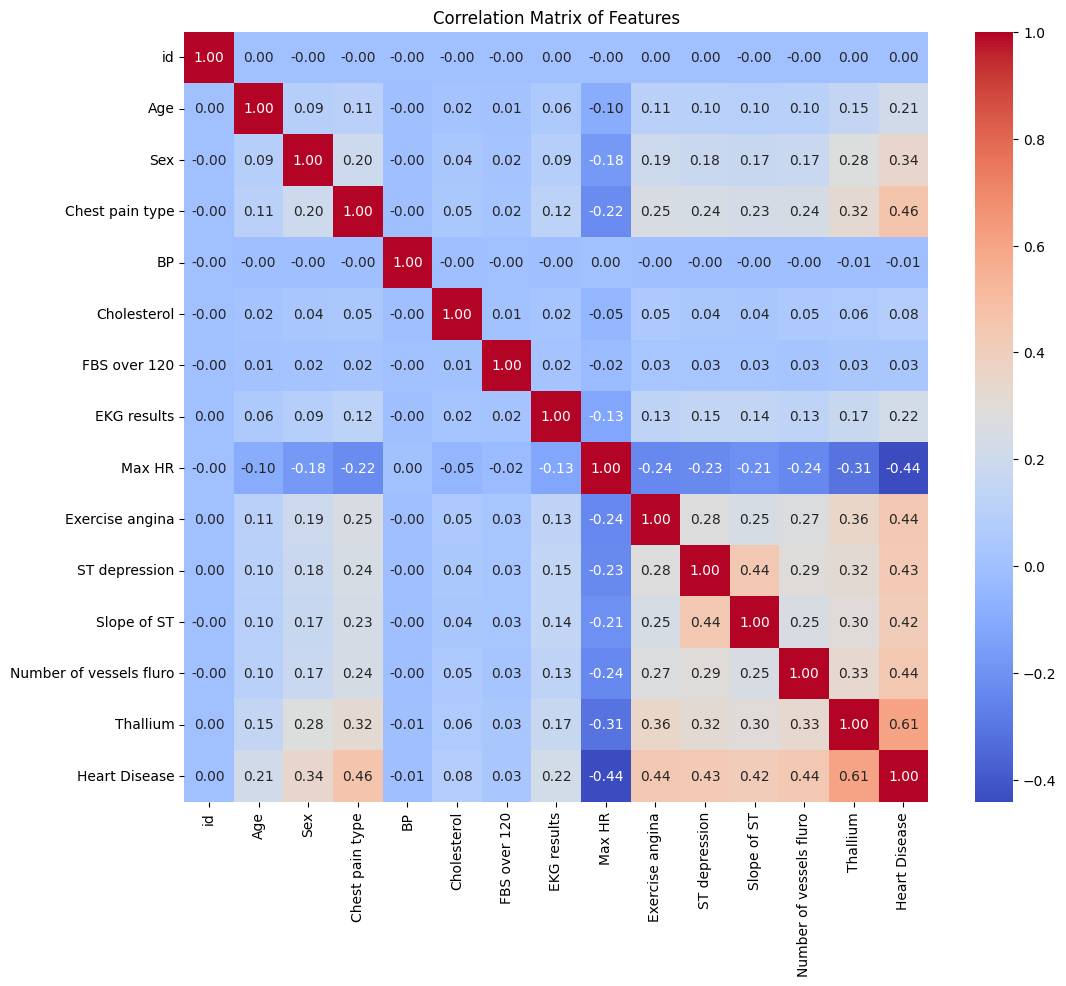

In [12]:
plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Features')
plt.show()

In [13]:
from scipy.stats import pearsonr

In [14]:
corr = df.corr()['Heart Disease'].sort_values(ascending=False)
print(corr)

Heart Disease              1.000000
Thallium                   0.605776
Chest pain type            0.460684
Exercise angina            0.441864
Number of vessels fluro    0.438604
ST depression              0.430641
Slope of ST                0.415050
Sex                        0.342446
EKG results                0.218961
Age                        0.212091
Cholesterol                0.082753
FBS over 120               0.033570
id                         0.000209
BP                        -0.005181
Max HR                    -0.440985
Name: Heart Disease, dtype: float64


In [15]:
raw_features = ['Thallium', 'Chest pain type', 'Exercise angina', 'Number of vessels fluro', 'ST depression','Max HR']
    


# Separate Features and Target

In [16]:
X = df[raw_features]
y = df['Heart Disease']

In [17]:
X.head()

,Thallium,Chest pain type,Exercise angina,Number of vessels fluro,ST depression,Max HR
0,7,4,1,2,3.6,158
1,3,1,0,0,0.0,171
2,3,2,0,0,0.0,151
3,3,3,0,0,1.0,150
4,3,4,1,3,3.8,125


In [18]:
y.head()

0    1
1    0
2    0
3    0
4    1
Name: Heart Disease, dtype: int64

# Train–Validation Split

In [19]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Training the model

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

# Fit the model
rf_model.fit(X_train_scaled, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
# Predictions
y_pred = rf_model.predict(X_val_scaled)

# Evaluating the model

In [40]:
from sklearn.metrics import roc_auc_score

In [41]:
auc_score = roc_auc_score(y_val, y_pred)
print("AUC-ROC:", auc_score)

AUC-ROC: 0.8722958021343301


# Import the Test Data and Sample Submission

In [ ]:
Test_data = pd.read_excel(r"C:\Users\Anthony Bannerman\Documents\heart disease analysis\test.xlsx")

In [ ]:
Test_data.head()

In [ ]:
Test_data.info()

In [ ]:
submission_data = pd.read_excel(r"C:\Users\Anthony Bannerman\Documents\heart disease analysis\sample_submission.xlsx")

In [ ]:
submission_data.head()

# Select the features

In [ ]:
raw_features = [
    'Thallium',
    'Chest pain type',
    'Exercise angina',
    'Number of vessels fluro',
    'ST depression',
    'Max HR'
]

X_test = Test_data[raw_features]


# Step 2: Predict probabilities (for AUC)

In [ ]:
y_test_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
Submission_data = pd.DataFrame({
    'id': Test_data['id'],
    'Heart Disease': y_test_prob
})

Submission_data["Heart Disease"] = y_test_prob

Submission_data.to_csv("submission.csv", index=False)

# What I discovered?

The model correctly ranks a randomly chosen patient with heart disease above a patient without disease 87% of the time.